# I.3 — The Mandelbrot Set

At the end of your very first notebook you ran some mystery code and this creature appeared.
Tonight you build it yourself and understand every line. The entire rule:

$$z \to z^2 + c$$

First, meet complex numbers — which, fresh off Module 2, you already understand:
a complex number **is a 2D vector** ($3 + 4i$ is the arrow to the point $(3, 4)$) with one twist
added: multiplying complex numbers *rotates and scales* the plane. That's it. That's the whole secret.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Python has complex numbers built in — it writes i as j.
c = 3 + 4j
print("as a 2D vector:", (c.real, c.imag))   # just the point (3, 4)
print("length of the arrow:", abs(c))        # Pythagoras: sqrt(3^2 + 4^2) = 5. Module 2!

# The twist: multiplying by 1j rotates the arrow 90 degrees anticlockwise.
z = 1 + 0j                                   # the arrow pointing east
for _ in range(4):
    z = z * 1j
    print(z)                                 # east -> north -> west -> south -> east

as a 2D vector: (3.0, 4.0)
length of the arrow: 5.0
1j
(-1+0j)
(-0-1j)
(1-0j)


In [3]:
# The game: pick a point c, start z at 0, apply z -> z^2 + c over and over.
# Question: does z stay near home, or fly off to infinity?
for c in [0.25 + 0.25j, 1 + 0j]:
    z = 0
    print(f"\nc = {c}")
    for i in range(10):
        z = z * z + c
        print(f"  step {i + 1:>2}:  |z| = {abs(z):,.4f}")


c = (0.25+0.25j)
  step  1:  |z| = 0.3536
  step  2:  |z| = 0.4507
  step  3:  |z| = 0.4701
  step  4:  |z| = 0.4100
  step  5:  |z| = 0.3351
  step  6:  |z| = 0.3496
  step  7:  |z| = 0.3903
  step  8:  |z| = 0.4061
  step  9:  |z| = 0.3940
  step 10:  |z| = 0.3749

c = (1+0j)
  step  1:  |z| = 1.0000
  step  2:  |z| = 2.0000
  step  3:  |z| = 5.0000
  step  4:  |z| = 26.0000
  step  5:  |z| = 677.0000
  step  6:  |z| = 458,330.0000
  step  7:  |z| = 210,066,388,901.0000
  step  8:  |z| = 44,127,887,745,906,175,377,408.0000
  step  9:  |z| = 1,947,270,476,915,296,285,689,291,011,464,375,055,838,871,552.0000
  step 10:  |z| = 3,791,862,310,265,925,368,983,295,389,282,095,720,671,991,592,314,004,219,343,115,081,777,413,793,648,295,637,290,057,728.0000


One point is **loyal** — its $z$ orbits close to home forever. The other **escapes** —
once $|z| > 2$ it's mathematically guaranteed to fly off to infinity.

The Mandelbrot set = the set of all loyal points. To draw it: make a grid of $c$ values covering
the plane (every pixel is one $c$), iterate them **all at once** with numpy, and colour each pixel
by *how many steps it survived* before escaping. Loyal points (never escaped) stay coloured 0.

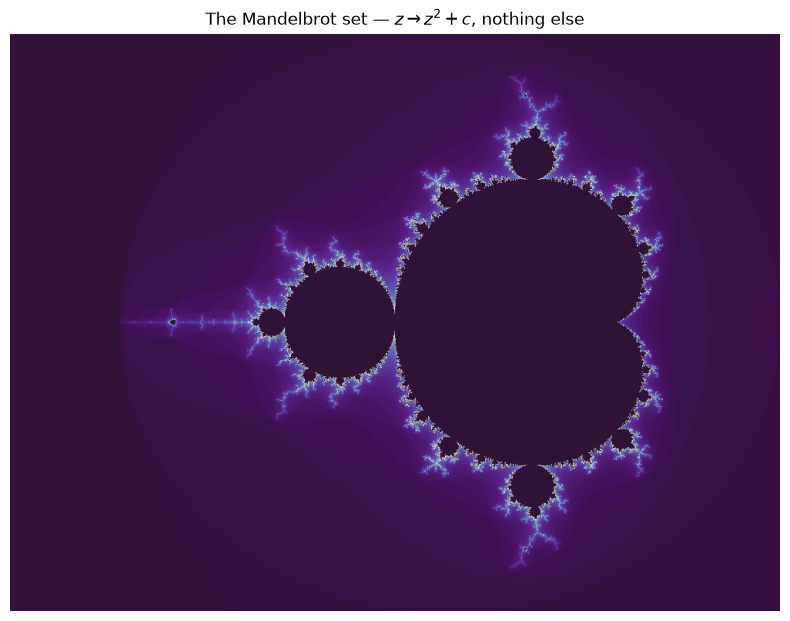

In [4]:
def mandelbrot(x_min, x_max, y_min, y_max, width=1000, steps=100):
    """Colour every pixel by how many steps it survived before escaping (0 = never escaped)."""
    height = int(width * (y_max - y_min) / (x_max - x_min))       # keep pixels square
    re = np.linspace(x_min, x_max, width)
    im = np.linspace(y_min, y_max, height)
    c = re[None, :] + 1j * im[:, None]        # broadcasting: a full 2D grid of c values
    z = np.zeros_like(c)                      # every z starts at 0
    escaped_at = np.zeros(c.shape)
    for step in range(1, steps + 1):
        alive = escaped_at == 0               # boolean mask: pixels still in the game
        z[alive] = z[alive] ** 2 + c[alive]   # iterate ONLY the survivors — whole grid, no loops
        escaped_at[alive & (np.abs(z) > 2)] = step
    return escaped_at

picture = mandelbrot(-2.5, 1.0, -1.3125, 1.3125)      # 1000 x 750 pixels = 750,000 games at once

plt.figure(figsize=(10, 7.5))
plt.imshow(picture, cmap="twilight_shifted", origin="lower",
           extent=[-2.5, 1.0, -1.3125, 1.3125])
plt.axis("off")
plt.title(r"The Mandelbrot set — $z \to z^2 + c$, nothing else")
plt.show()

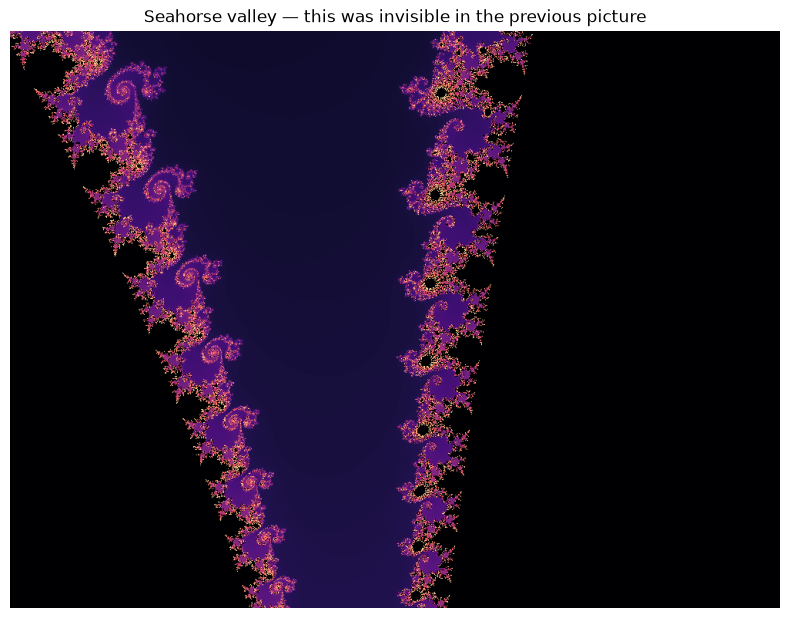

In [5]:
# Now the part no textbook can convey: ZOOM IN. This window is "seahorse valley",
# a region on the boundary. Deeper zooms need more steps to resolve the fine detail.
zoom = mandelbrot(-0.78, -0.72, 0.075, 0.12, width=1000, steps=300)

plt.figure(figsize=(10, 7.5))
plt.imshow(zoom, cmap="magma", origin="lower", extent=[-0.78, -0.72, 0.075, 0.12])
plt.axis("off")
plt.title("Seahorse valley — this was invisible in the previous picture")
plt.show()

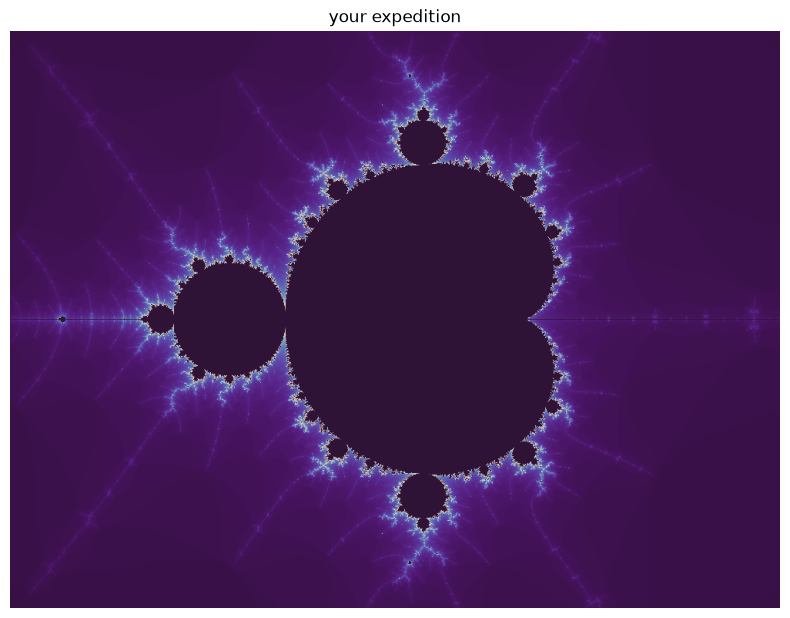

In [6]:
# YOUR TURN — go exploring. Paste in any window. Classic destinations:
#   x: -1.79, -1.73    y: -0.0225, 0.0225    (a perfect BABY Mandelbrot, living on the antenna)
#   x:  0.26,  0.32    y:  0.0,    0.045     (elephant valley)
#   x: -0.750, -0.742  y:  0.100,  0.106     (spiral country — use steps=400)
# Rules of the road: keep width <= 1000, and raise steps as you go deeper.
# (Colours are yours too: try cmap="magma", "twilight", "viridis".)
pic = mandelbrot(-1.79, -1.73, -0.0225, 0.0225, width=1000, steps=300)

plt.figure(figsize=(10, 7.5))
plt.imshow(pic, cmap="twilight_shifted", origin="lower", extent=[-1.79, -1.73, -0.0225, 0.0225])
plt.axis("off")
plt.title("your expedition")
plt.show()

## What you just saw

The boundary of this set is **infinitely** detailed. Zoom a million times, a billion — it never
smooths out, and it keeps sprouting perfect miniature copies of itself. Mathematicians call it
the most complex object in mathematics. Its complete definition is seven characters: $z^2 + c$.

Look at what you actually did tonight: treated complex numbers as 2D vectors (Module 2),
iterated a quadratic (Modules 0–1), and computed 750,000 of those games *simultaneously* with a
numpy grid and boolean masks — which is precisely how images and batches flow through a real
neural network. No loops over pixels. Whole-array thinking. You now think the way GPUs think.

**The thread:** simple rules, iterated, create unbounded complexity. A neural network is a simple
rule — multiply, add, bend — iterated layer after layer. You've now seen what iteration can build.

*Done? Send Claude a screenshot of the best place you found. Coordinates or it didn't happen.*